# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)

b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 

c. In PLS, how is the first direction `Z₁` computed? 

d. What are some similarities and differences between PLS and penalized regression? 

### Our Answers
A. The key difference is that PCR identifies directions that explain the most variance among the predictors in an unsupervised way, meaning the response is not used to construct the components. In contrast, PLS is a supervised approach that uses the response to identify directions that maximize the covariance between the predictors and the target.

B. Because PCR doesn't use the response to find the directions that are useful for predicting the response its considered unsupervised and that could mean that it doesn't pick the good directions.

C. $Z_1 = \sum_{j=1}^p \phi_{j1} X_j$is computed by setting each coefficient $\phi_{j1}$ equal to the slope from a simple linear regression of $Y$ onto $X_j$.

D. Both PLS and penalized regression introduce bias to shrink variance and effectively resolve multicollinearity and high dimensionality ($p > n$). However, while PLS achieves this via dimension reduction, penalized regression retains the original predictor space and shrinks the regression coefficients directly using penalty terms like L2 or L1 norms. 

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

What is the goal of this step?
- The goal of this step is to create a toy dataset based on randomly simulated data. We pick a random random state, number of samples, the size of the covariance matrix, the random feature data and the random target data based on the feature data, the 2nd PCA component and a random bias.

Why is this important in a PLS regression pipeline?
- Initializing data to use in the PLS regression pipeline is crucial to be able to make the model at all. In addition, by using the coefficient from PCA with the feature data and a random bias, we created a target variable.

What does the output mean or tell us?
- Nothing at this point because so far this is only initializing the simulated data.

In [2]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split

X_train, X_report, y_train, y_report = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)

,n_components,1
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


What is the goal of this step?
- The goal of this step is to split the data into train and test sets so that we are not using the whole dataset to create our model. In addition, we initialize the PLS Regression function with one component and fit it to the training data.

Why is this important in a PLS regression pipeline?
- Splitting the data into training and testing data will ensure there is no data leakage and that when we have finished creating our model, we can use the test data to truly evaluate the performance of our model. It's also crucial to create our PLS Regression model and fit it on only the training data so that the test data can be used to simulate performance once implemented.

What does the output mean or tell us?
- We have created a PLSRegression model and fitted it on the training data with only one component while otherwise keeping the model standard out of the box.

### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

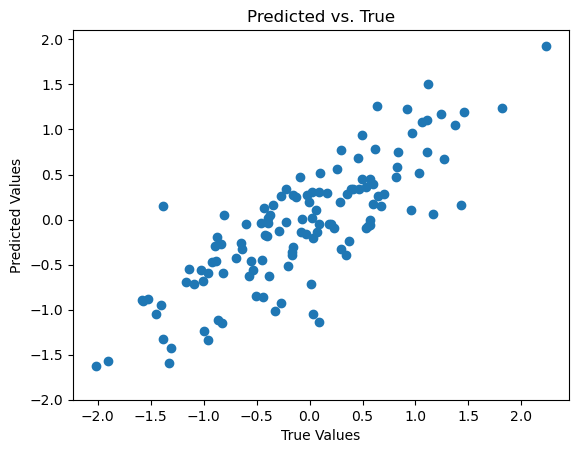

In [3]:
pls2 = PLSRegression(n_components=2)
pls2.fit(X_train, y_train)

y_pred = pls2.predict(X_report)
plt.scatter(y_report, y_pred)
plt.title('Predicted vs. True')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.xticks([-2,-1.5,-1,-0.5,0,0.5,1,1.5,2])
plt.yticks([-2,-1.5,-1,-0.5,0,0.5,1,1.5,2])
plt.show()

What is the goal of this step?
- Refitting the PLS model with 2 components and plotting the predicted vs. actual response values on the reporting set to get an idea of performance.

Why is this important in a PLS regression pipeline?
- This is important to improve our model. We need to experiment and see if performance has improved.

What does the output mean or tell us?
- This shows us that adding more components to the PLS model has improved performance.

In [4]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_report, y_pred)
mse = mean_squared_error(y_report, y_pred)
print(f'The R2 Score is {r2:.4f} and the Mean Squared Error is {mse:.4f}')

The R2 Score is 0.6732 and the Mean Squared Error is 0.2166


What is the goal of this step?
- This step is another way to view our current performance with our PLS model because we are using the R2 Score and Mean Squared Error as indicators of how our model is performing.

Why is this important in a PLS regression pipeline?
- This is important because we need to understand how our model is performing and see if we need to continue to improve it or not.

What does the output mean or tell us?
- The R2 Score output means that our current PLS model explains about 67% of the variance in the target variable with the features used currently. The Mean Squared Error being about 0.21 means that our model is predicting the response very well.

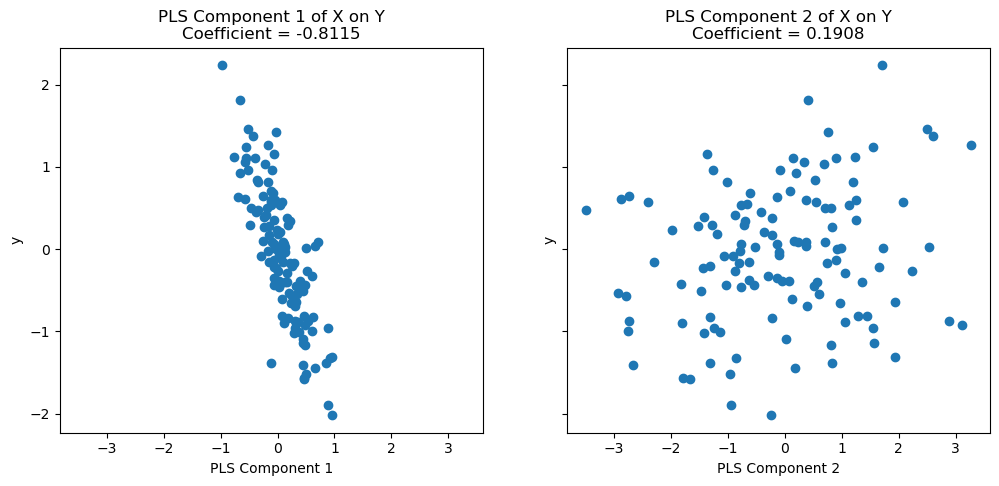

In [7]:
X_report_trans = pls2.transform(X_report)
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    coef = np.corrcoef(X_report_trans[:,i], y_report)[0,1]
    axes[i].scatter(X_report_trans[:,i], y_report)
    axes[i].set_xlabel(f'PLS Component {i+1}')
    axes[i].set_ylabel('y')
    axes[i].set_title(f'PLS Component {i+1} of X on Y\nCoefficient = {coef:.4f}')

What is the goal of this step?
- The goal of this step is to visualize how each component of X relates to the response Y with a scatterplot.

Why is this important in a PLS regression pipeline?
- This is important to understand how our components correlate with the response and to ensure that our most correlated feature is the 1st one.

What does the output mean or tell us?
- The output shows us that the 1st component of X is the most correlated with Y.

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

What do the learned PLS components represent in your dataset?
- Each component is a combination of the two predictors, with weights chosen using y so that the component captures as much shared variation with the response as possible. Since y was constructed from the second principal direction of X, the first PLS component aligns closely with that same signal, showing a correlation with y of about -0.81, compared to just 0.19 for the second component.

Did increasing the number of components improve performance?
- Increasing the number of components only improved performance slightly, R² rose from 0.658 with one component to 0.673 with two, while MSE dropped from 0.226 to 0.217. Which shows that nearly all of the predictive signal in the data was already captured by the first component alone.

What makes PLS different from PCA?
- PCA finds directions of maximum variance in X without using y, so it's unsupervised. PLS uses y to choose directions that are also predictive of the response, so it's supervised.

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

Full dataset shape: (165, 1108)
X shape: (165, 1107) | y shape: (165,)
Train/reporting split: (115, 1107) (50, 1107)
Predictors remaining after variance thresholding: 632 (out of 1107)
Selected number of PLS components: 3
Cross-validated R2 on training set (PLS): 0.330
Reporting-set R2 (PLS): 0.408
Reporting-set MSE (PLS): 151.569


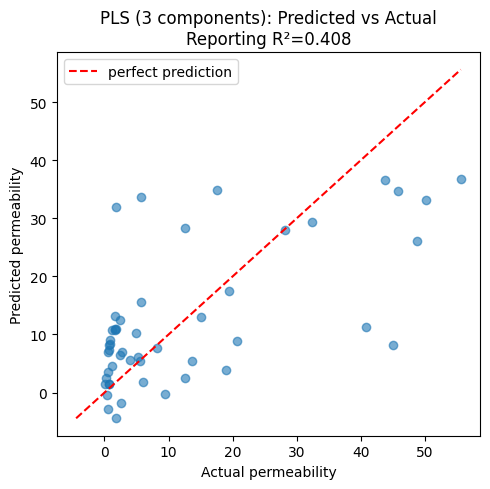

--- Penalized PCR (Lasso) ---
  PCA components retained (95% variance): 43
  Best params: {'reg__alpha': 1}
  Cross-validated R2 (training): 0.307
  Reporting-set R2: 0.454
  Reporting-set MSE: 139.721
--- Penalized PCR (Ridge) ---
  PCA components retained (95% variance): 43
  Best params: {'reg__alpha': 100}
  Cross-validated R2 (training): 0.320
  Reporting-set R2: 0.435
  Reporting-set MSE: 144.738
--- Penalized PCR (ElasticNet) ---
  PCA components retained (95% variance): 43
  Best params: {'reg__alpha': 10, 'reg__l1_ratio': 0.2}
  Cross-validated R2 (training): 0.325
  Reporting-set R2: 0.368
  Reporting-set MSE: 161.748


,Model,CV R2 (train),Reporting R2,Reporting MSE
0,PLS,0.330248,0.408126,151.568988
1,Lasso,0.306988,0.454393,139.720729
2,Ridge,0.319975,0.434799,144.738357
3,ElasticNet,0.324507,0.368376,161.748189


In [1]:
# a. Prepare Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

url = "https://raw.githubusercontent.com/UVADS/DS-4021/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv"
df = pd.read_csv(url)

X = df.drop(columns=["permeability"]).values
y = df["permeability"].values
print("Full dataset shape:", df.shape)
print("X shape:", X.shape, "| y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
print("Train/reporting split:", X_train.shape, X_test.shape)

# b. Create a pipeline
pls_pipe = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression()),
])

# c. Optimize and train
param_grid = {"pls__n_components": list(range(1, 21))}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pls_grid = GridSearchCV(pls_pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1)
pls_grid.fit(X_train, y_train)

n_features_after_vt = pls_grid.best_estimator_.named_steps["vt"].transform(X_train).shape[1]
best_n_components = pls_grid.best_params_["pls__n_components"]
best_cv_r2 = pls_grid.best_score_

print(f"Predictors remaining after variance thresholding: {n_features_after_vt} (out of {X_train.shape[1]})")
print(f"Selected number of PLS components: {best_n_components}")
print(f"Cross-validated R2 on training set (PLS): {best_cv_r2:.3f}")

# d. Evaluate
y_pred_pls = pls_grid.predict(X_test).ravel()
pls_test_r2 = r2_score(y_test, y_pred_pls)
pls_test_mse = mean_squared_error(y_test, y_pred_pls)
print(f"Reporting-set R2 (PLS): {pls_test_r2:.3f}")
print(f"Reporting-set MSE (PLS): {pls_test_mse:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_pls, alpha=0.6)
lims = [min(y_test.min(), y_pred_pls.min()), max(y_test.max(), y_pred_pls.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual permeability")
plt.ylabel("Predicted permeability")
plt.title(f"PLS ({best_n_components} components): Predicted vs Actual\nReporting R²={pls_test_r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# e. Compare
pcr_results = {}

model_configs = {
    "Lasso": (Lasso(max_iter=10000), {"reg__alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "Ridge": (Ridge(max_iter=10000), {"reg__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}),
    "ElasticNet": (
        ElasticNet(max_iter=10000),
        {"reg__alpha": [0.001, 0.01, 0.1, 1, 10], "reg__l1_ratio": [0.2, 0.5, 0.8]},
    ),
}

for name, (estimator, grid_params) in model_configs.items():
    pcr_pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("reg", estimator),
    ])
    grid = GridSearchCV(pcr_pipe, grid_params, cv=cv, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    n_pca_components = grid.best_estimator_.named_steps["pca"].n_components_

    pcr_results[name] = {
        "best_params": grid.best_params_,
        "cv_r2": grid.best_score_,
        "test_r2": test_r2,
        "test_mse": test_mse,
        "n_pca_components": n_pca_components,
    }

    print(f"--- Penalized PCR ({name}) ---")
    print(f"  PCA components retained (95% variance): {n_pca_components}")
    print(f"  Best params: {grid.best_params_}")
    print(f"  Cross-validated R2 (training): {grid.best_score_:.3f}")
    print(f"  Reporting-set R2: {test_r2:.3f}")
    print(f"  Reporting-set MSE: {test_mse:.3f}")

summary = pd.DataFrame({
    "Model": ["PLS"] + list(pcr_results.keys()),
    "CV R2 (train)": [best_cv_r2] + [pcr_results[m]["cv_r2"] for m in pcr_results],
    "Reporting R2": [pls_test_r2] + [pcr_results[m]["test_r2"] for m in pcr_results],
    "Reporting MSE": [pls_test_mse] + [pcr_results[m]["test_mse"] for m in pcr_results],
})
summary

f.

Which model performed best?
- Lasso-PCR had the best reporting-set performance (R² = 0.454)

Would you trust any of your models enough to replace the permeability lab assay?
- No. R² around 0.4–0.45 means less than half the variance in permeability is explained. Which is useful for screening  compounds, not for replacing a lab measurement.

What would be the trade-offs of doing so?
- A model is low-cost and efficient, which means a lot more compounds can be screened early on. The trade-off is accuracy, a model that only explains 40–45% of the variance in permeability is going to get some predictions wrong, so a truly permeable compound could get filtered out before ever being tested, or a poor one could advance further before anyone catches the mistake.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

Our group didn't encounter a huge problem but moving forward, it might be helpful to divide the notebooks by section so we aren't all working through the entire analysis individually. Splitting up tasks would help reduce overlap and give everyone a bit more breathing room instead of rushing near the finish line. We could then come together to review each other’s parts, which would make the workflow feel much smoother and more manageable.